# 01 — Exploratory Data Analysis

This notebook explores the raw OHLCV data and all engineered technical indicators before any modeling.

In [1]:
import sys
sys.path.append('..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi'] = 120
plt.rcParams['figure.figsize'] = (14, 5)
sns.set_style('darkgrid')

print('Libraries loaded ✓')

Libraries loaded ✓


## 1. Download Data

In [2]:
# --- Download via yfinance ---
import yfinance as yf

TICKER = 'AAPL'
START  = '2018-01-01'
END    = '2024-01-01'

df_raw = yf.download(TICKER, start=START, end=END, auto_adjust=True)
df_raw.columns = df_raw.columns.get_level_values(0)
df_raw = df_raw[['Open','High','Low','Close','Volume']]
df_raw.index = pd.to_datetime(df_raw.index)
df_raw = df_raw.sort_index().dropna()

print(f'Shape: {df_raw.shape}')
df_raw.head()

[*********************100%***********************]  1 of 1 completed

Shape: (1509, 5)


Price,Open,High,Low,Close,Volume
Date,,,,,
2018-01-02,39.776190,40.276431,39.565806,40.267078,102223600
2018-01-03,40.330191,40.802382,40.196951,40.260063,118071600
2018-01-04,40.332521,40.549917,40.224995,40.447063,89738400
2018-01-05,40.542916,40.994067,40.451751,40.907578,94640000
2018-01-08,40.755638,41.050171,40.657457,40.755638,82271200


## 2. Basic Statistics

In [3]:
df_raw.describe().round(2)

Price,Open,High,Low,Close,Volume
count,1509.00,1509.00,1509.00,1509.00,1.509000e+03
mean,107.52,108.75,106.39,107.62,1.073284e+08
std,50.80,51.31,50.31,50.84,5.513287e+07
min,34.16,34.57,33.69,33.74,2.404830e+07
25%,51.28,51.94,50.76,51.14,7.078370e+07
50%,120.38,121.49,118.74,120.24,9.296430e+07
75%,149.77,151.69,147.95,149.94,1.280440e+08
max,195.80,197.39,194.80,195.89,4.265100e+08


In [4]:
# Missing values check
print('Missing values:')
print(df_raw.isnull().sum())
print(f'\nDate range: {df_raw.index.min().date()} → {df_raw.index.max().date()}')
print(f'Total trading days: {len(df_raw)}')

Missing values:
Price
Open      0
High      0
Low       0
Close     0
Volume    0
dtype: int64

Date range: 2018-01-02 → 2023-12-29
Total trading days: 1509


## 3. OHLCV Price Chart

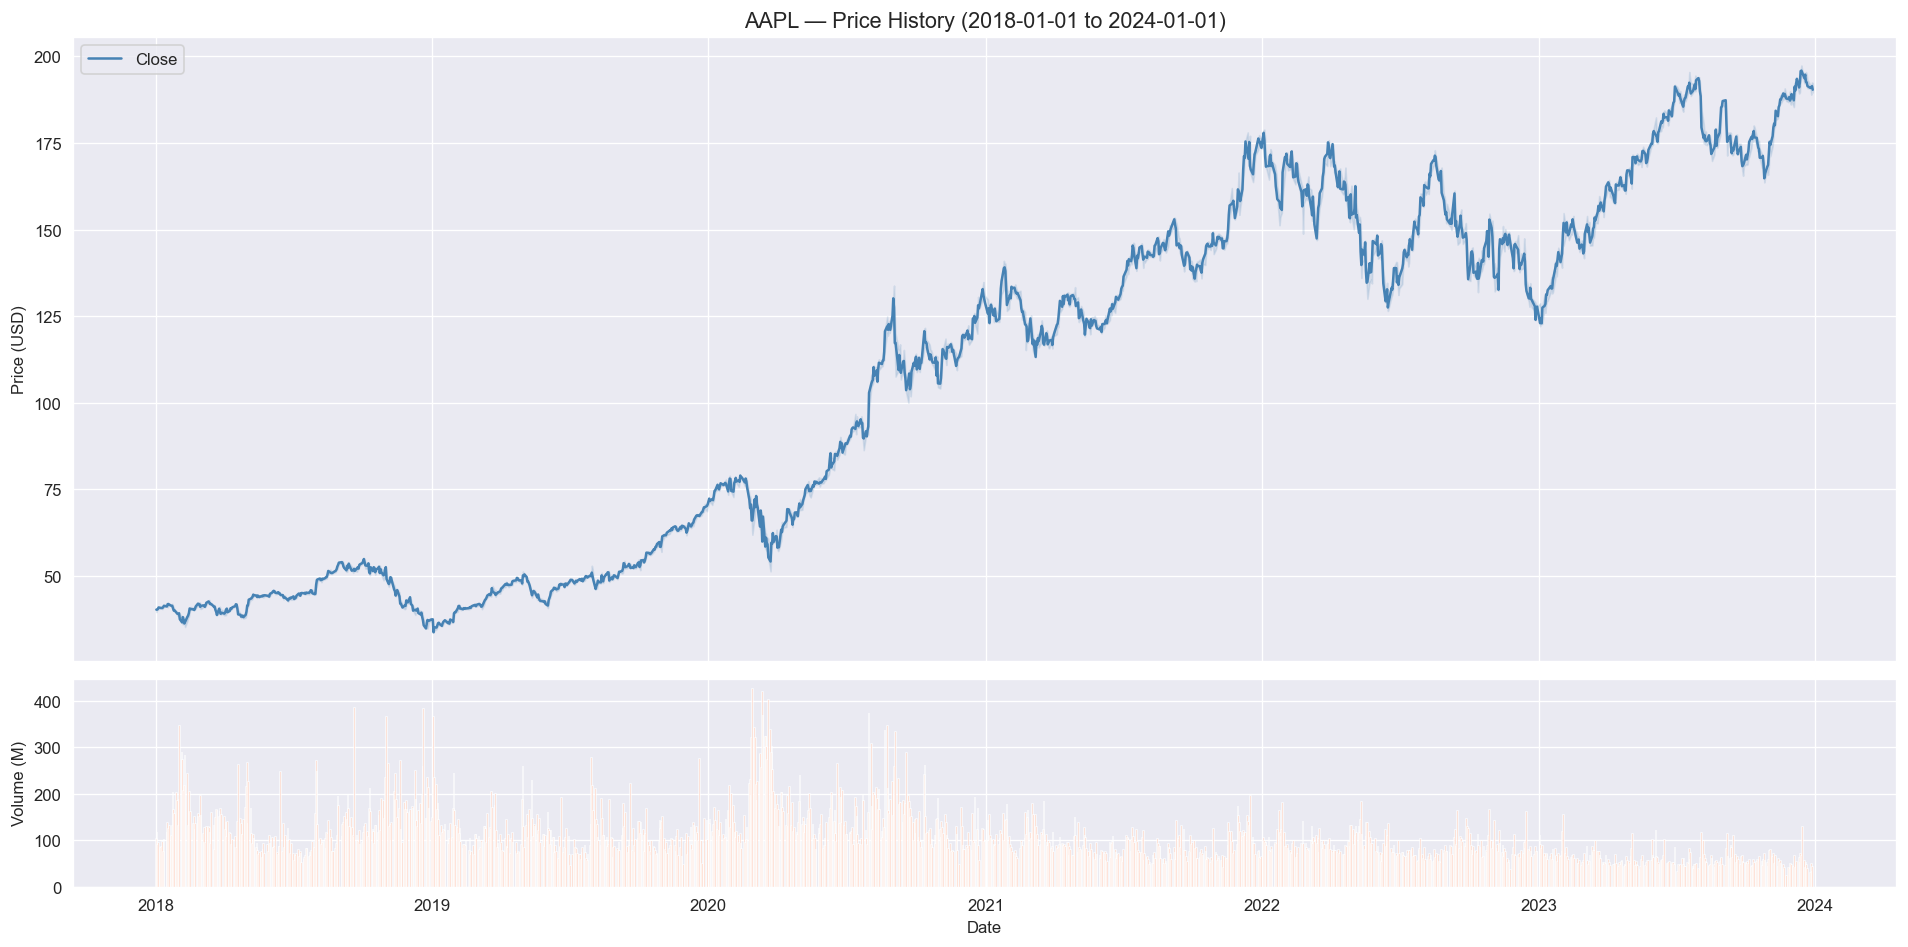

In [5]:
fig, axes = plt.subplots(2, 1, figsize=(16, 8), sharex=True,
                          gridspec_kw={'height_ratios': [3, 1]})

# Price
axes[0].plot(df_raw.index, df_raw['Close'], color='steelblue', linewidth=1.5, label='Close')
axes[0].fill_between(df_raw.index, df_raw['Low'], df_raw['High'], alpha=0.15, color='steelblue')
axes[0].set_title(f'{TICKER} — Price History ({START} to {END})', fontsize=13)
axes[0].set_ylabel('Price (USD)')
axes[0].legend()

# Volume
axes[1].bar(df_raw.index, df_raw['Volume'] / 1e6, color='coral', alpha=0.7, width=1)
axes[1].set_ylabel('Volume (M)')
axes[1].set_xlabel('Date')

plt.tight_layout()
plt.show()

## 4. Daily Returns Distribution

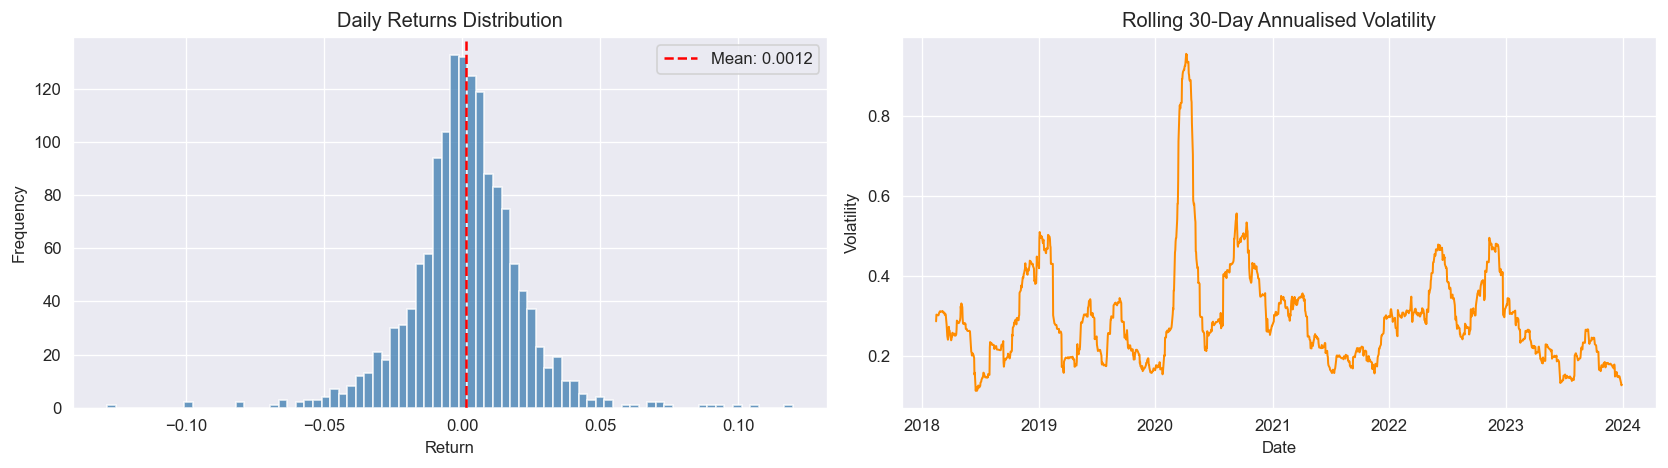

Mean daily return : 0.00123
Std daily return  : 0.01995
Skewness          : -0.0366
Kurtosis          : 4.9192


In [6]:
returns = df_raw['Close'].pct_change().dropna()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Histogram
axes[0].hist(returns, bins=80, color='steelblue', edgecolor='white', alpha=0.8)
axes[0].axvline(returns.mean(), color='red', linestyle='--', label=f'Mean: {returns.mean():.4f}')
axes[0].set_title('Daily Returns Distribution')
axes[0].set_xlabel('Return'); axes[0].set_ylabel('Frequency')
axes[0].legend()

# Rolling volatility
vol_30 = returns.rolling(30).std() * np.sqrt(252)  # annualised
axes[1].plot(vol_30, color='darkorange', linewidth=1.2)
axes[1].set_title('Rolling 30-Day Annualised Volatility')
axes[1].set_xlabel('Date'); axes[1].set_ylabel('Volatility')

plt.tight_layout()
plt.show()

print(f'Mean daily return : {returns.mean():.5f}')
print(f'Std daily return  : {returns.std():.5f}')
print(f'Skewness          : {returns.skew():.4f}')
print(f'Kurtosis          : {returns.kurtosis():.4f}')

## 5. Technical Indicators

In [7]:
from src.features import build_features, get_feature_columns

df = build_features(df_raw)
feat_cols = get_feature_columns(df)
print(f'Total features: {len(feat_cols)}')
print('Features:', feat_cols)

[features] Dropped 50 NaN rows after feature engineering.
[features] Final shape: (1459, 33)  |  Columns: 33
Total features: 32
Features: ['Open', 'High', 'Low', 'Close', 'Volume', 'SMA_7', 'EMA_7', 'SMA_21', 'EMA_21', 'SMA_50', 'EMA_50', 'RSI', 'MACD', 'MACD_Signal', 'MACD_Histogram', 'BB_Upper', 'BB_Middle', 'BB_Lower', 'BB_Width', 'BB_Pct', 'Volume_SMA20', 'Volume_Ratio', 'OBV', 'Daily_Return', 'HL_Range', 'OC_Body', 'Close_Lag1', 'Close_Lag2', 'Close_Lag3', 'Close_Lag5', 'Volatility_7', 'Volatility_21']


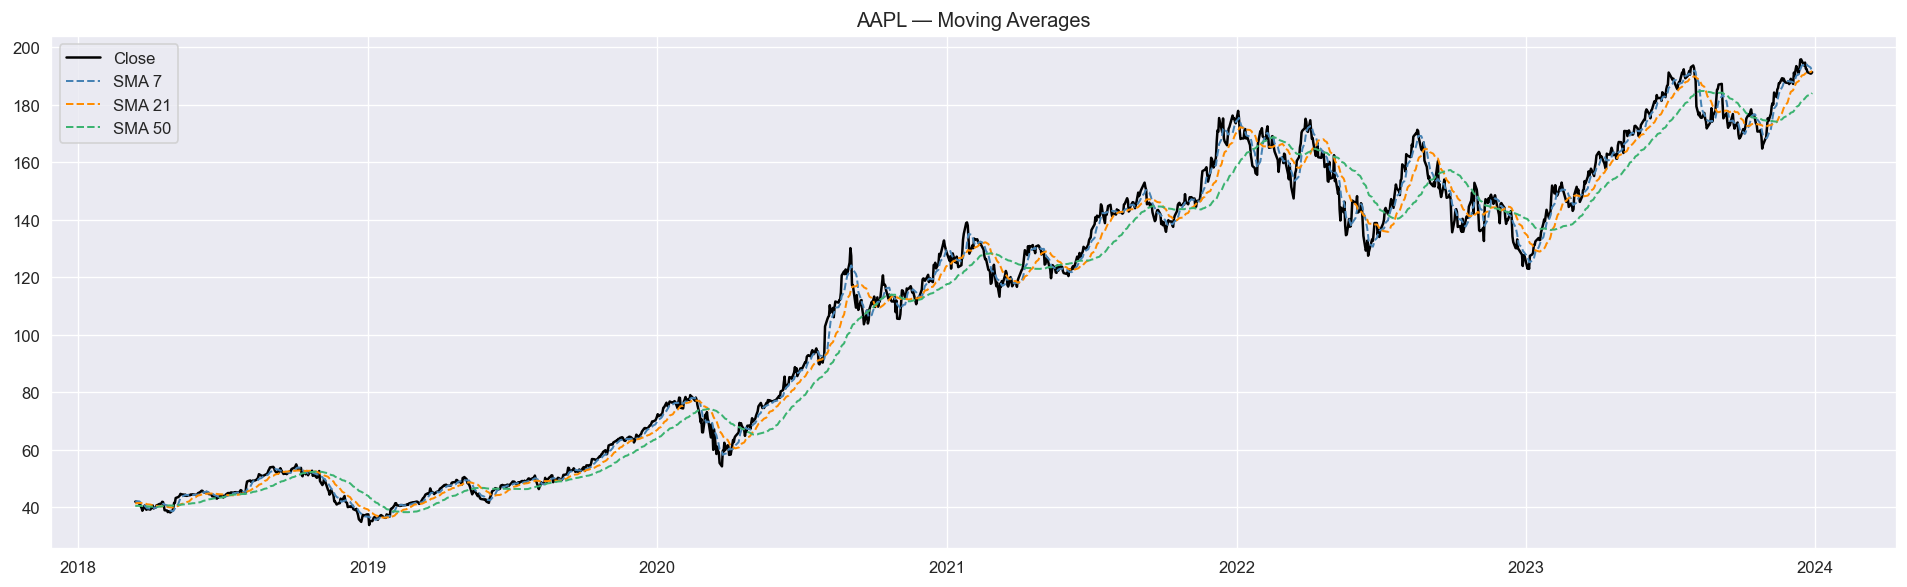

In [8]:
# Moving Averages
plt.figure(figsize=(16, 5))
plt.plot(df.index, df['Close'],   label='Close',  color='black', linewidth=1.5)
plt.plot(df.index, df['SMA_7'],   label='SMA 7',  color='steelblue', linewidth=1.2, linestyle='--')
plt.plot(df.index, df['SMA_21'],  label='SMA 21', color='darkorange', linewidth=1.2, linestyle='--')
plt.plot(df.index, df['SMA_50'],  label='SMA 50', color='mediumseagreen', linewidth=1.2, linestyle='--')
plt.title(f'{TICKER} — Moving Averages')
plt.legend(); plt.tight_layout(); plt.show()

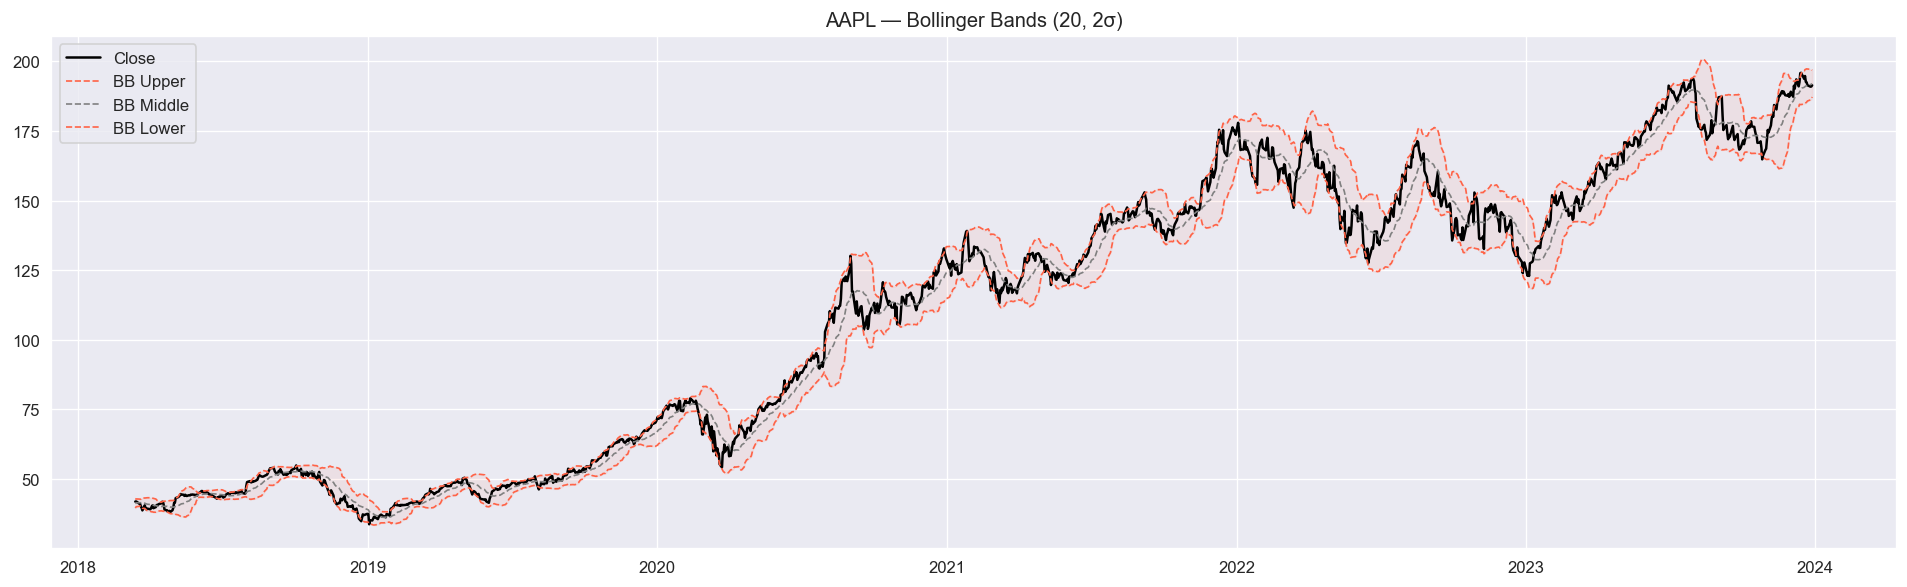

In [9]:
# Bollinger Bands
plt.figure(figsize=(16, 5))
plt.plot(df.index, df['Close'],     label='Close',  color='black', linewidth=1.5)
plt.plot(df.index, df['BB_Upper'],  label='BB Upper', color='tomato', linewidth=1, linestyle='--')
plt.plot(df.index, df['BB_Middle'], label='BB Middle', color='grey', linewidth=1, linestyle='--')
plt.plot(df.index, df['BB_Lower'],  label='BB Lower', color='tomato', linewidth=1, linestyle='--')
plt.fill_between(df.index, df['BB_Lower'], df['BB_Upper'], alpha=0.08, color='tomato')
plt.title(f'{TICKER} — Bollinger Bands (20, 2σ)')
plt.legend(); plt.tight_layout(); plt.show()

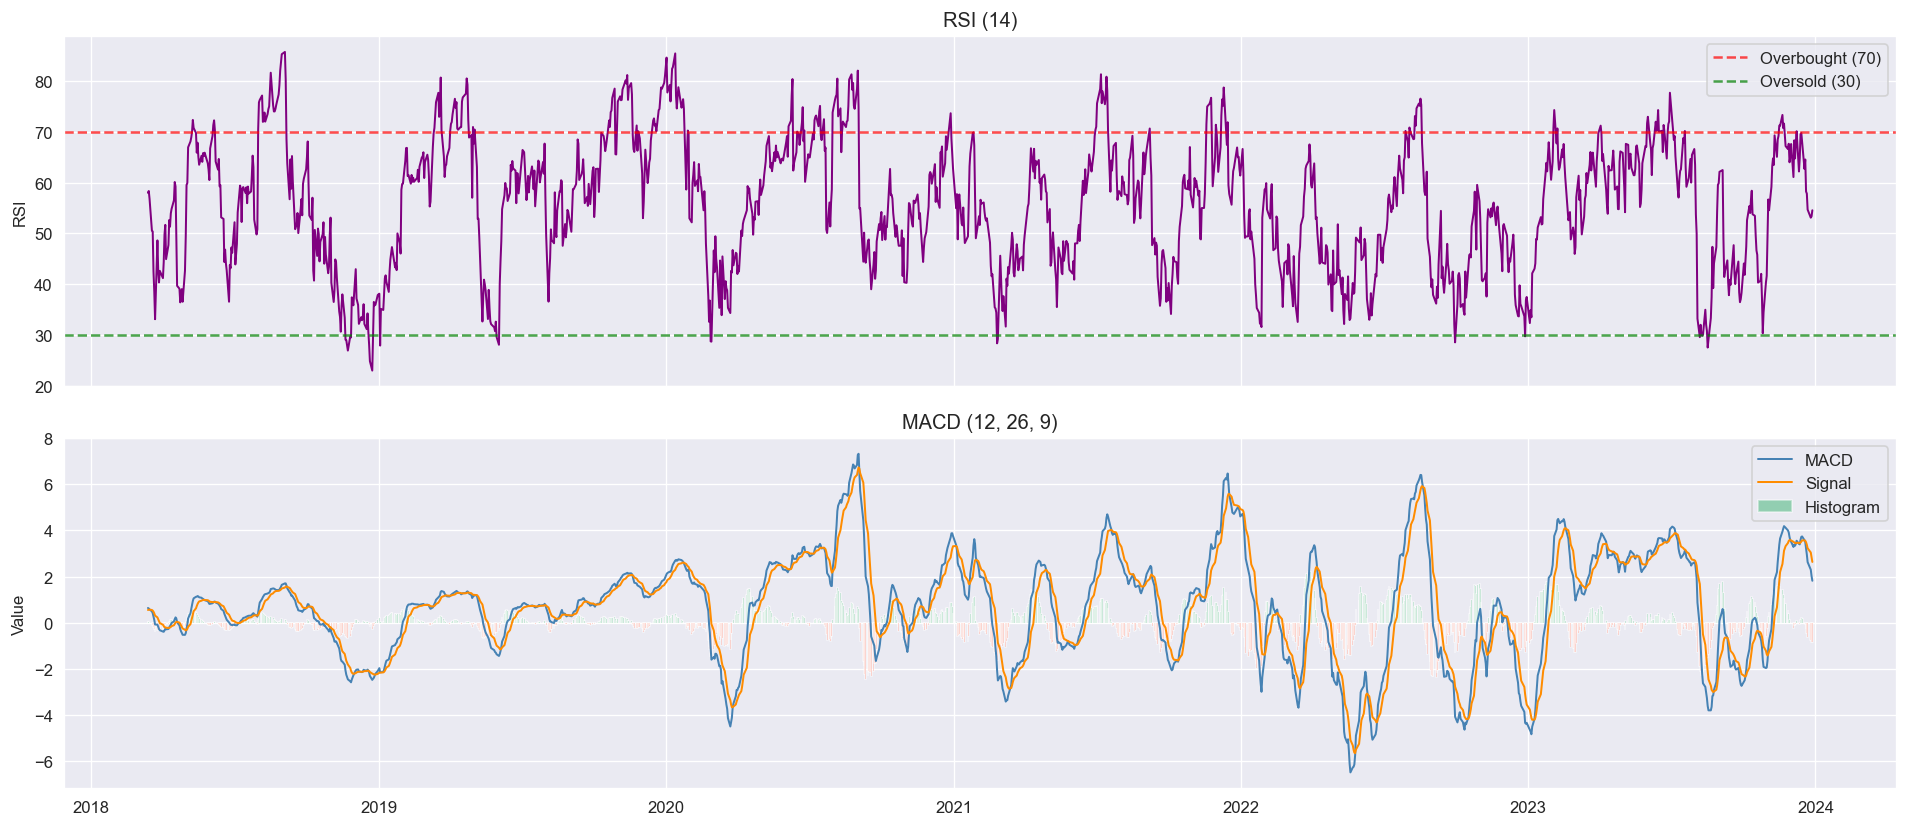

In [10]:
# RSI + MACD panel
fig, axes = plt.subplots(2, 1, figsize=(16, 7), sharex=True)

axes[0].plot(df.index, df['RSI'], color='purple', linewidth=1.2)
axes[0].axhline(70, color='red',   linestyle='--', alpha=0.7, label='Overbought (70)')
axes[0].axhline(30, color='green', linestyle='--', alpha=0.7, label='Oversold (30)')
axes[0].set_title('RSI (14)')
axes[0].set_ylabel('RSI'); axes[0].legend()

axes[1].plot(df.index, df['MACD'],        label='MACD',   color='steelblue', linewidth=1.2)
axes[1].plot(df.index, df['MACD_Signal'], label='Signal', color='darkorange', linewidth=1.2)
axes[1].bar(df.index, df['MACD_Histogram'], color=df['MACD_Histogram'].apply(
    lambda x: 'mediumseagreen' if x >= 0 else 'tomato'), width=1, alpha=0.5, label='Histogram')
axes[1].set_title('MACD (12, 26, 9)')
axes[1].set_ylabel('Value'); axes[1].legend()

plt.tight_layout(); plt.show()

## 6. Correlation Heatmap

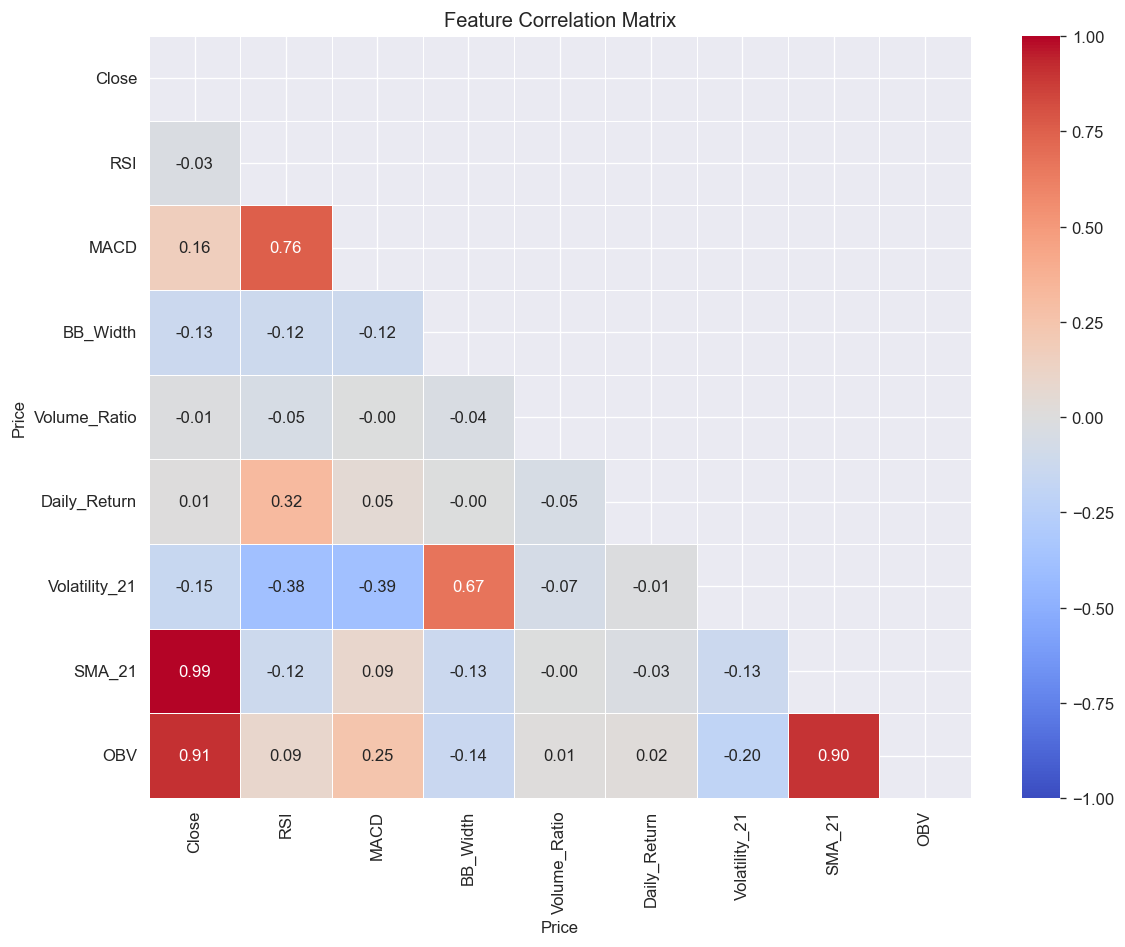

In [11]:
key_cols = ['Close', 'RSI', 'MACD', 'BB_Width', 'Volume_Ratio',
            'Daily_Return', 'Volatility_21', 'SMA_21', 'OBV']

corr = df[key_cols].corr()

plt.figure(figsize=(10, 8))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            mask=mask, vmin=-1, vmax=1, linewidths=0.5)
plt.title('Feature Correlation Matrix')
plt.tight_layout(); plt.show()

## 7. Target Variable Analysis

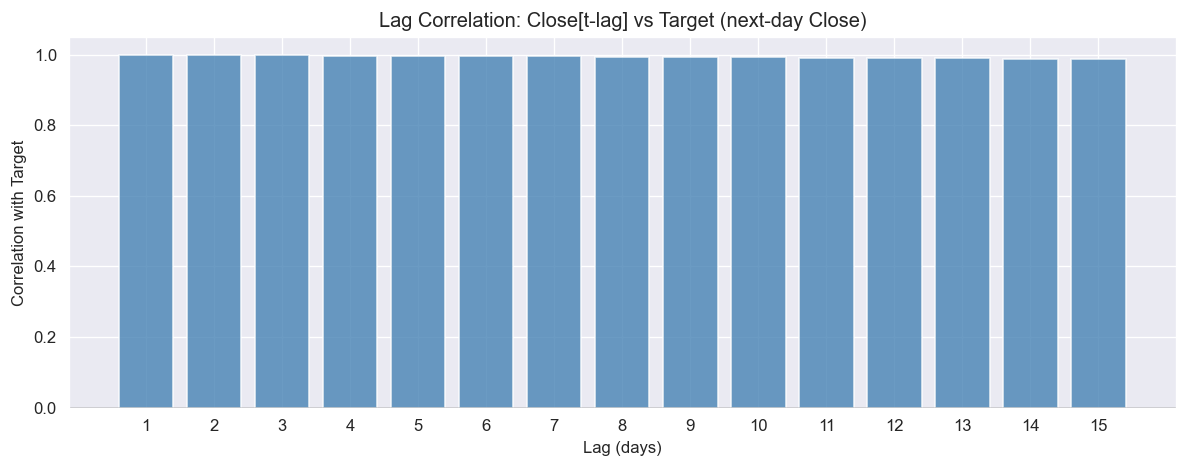

In [12]:
# Target = next-day Close — already in df['Target']
# Lag correlation: how well does today's close predict tomorrow's?
lags = range(1, 16)
lag_corr = [df['Close'].corr(df['Target'].shift(l)) for l in lags]

plt.figure(figsize=(10, 4))
plt.bar(lags, lag_corr, color='steelblue', alpha=0.8)
plt.axhline(0, color='black', linewidth=0.8)
plt.xlabel('Lag (days)'); plt.ylabel('Correlation with Target')
plt.title('Lag Correlation: Close[t-lag] vs Target (next-day Close)')
plt.xticks(list(lags))
plt.tight_layout(); plt.show()

In [13]:
print('EDA complete ✓')
print(f'Dataset ready for modeling: {df.shape[0]} rows × {df.shape[1]} columns')

EDA complete ✓
Dataset ready for modeling: 1459 rows × 33 columns
